# Unit 5 - 12 marks
- Decision Tree
- KNN (K nearest neighbour)
- Random Forest
- SVM (Support Vector Machines)

## classification model in machine learning
- **Data:** Divided into predefined, discrete categories
- **Goal:** Assign an input to one of the categories
- **Model output:** A specific category from a set
- 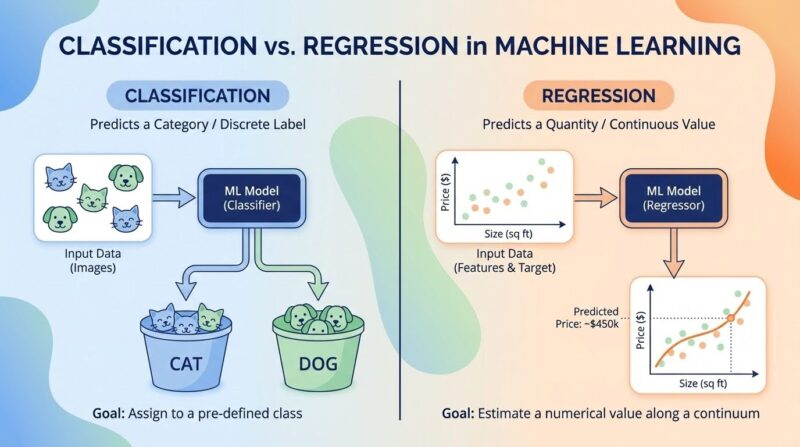

# Decision Tree

## decision tree python implemention of job offer dataset

### import libraries

In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier , plot_tree
import matplotlib.pyplot as plt
import seaborn as sns

### import the data

In [2]:
df = pd.read_csv('job_offers.csv')
df.head(2)

,CGPA,Communication,Aptitude,ProgrammingSkill,JobOffered
0,2,1,1,1,1
1,1,1,1,1,1


In [3]:
# define feature and target
x = df.drop(columns = ['JobOffered'])
y = df['JobOffered']
print(x.shape)
print(y.shape)

(20, 4)
(20,)


### create model

In [4]:
dtree = DecisionTreeClassifier(criterion='entropy' , max_depth=3)

In [5]:
# fit the model
dtree.fit(x , y)

,criterion,'entropy'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## predictions

In [6]:
predictions = dtree.predict(x)

In [7]:
print(predictions)

[1 1 0 0 1 1 0 0 1 1 0 0 1 0 0 0 0 0 0 1]


## Evalution matrics in classification model

In [8]:
from sklearn.metrics import confusion_matrix,accuracy_score , precision_score , recall_score , f1_score , classification_report

## confusion matrix

In [10]:
cm = confusion_matrix(y , predictions)
print("Confusion matrix - \n",cm)

Confusion matrix - 
 [[11  0]
 [ 1  8]]


In [11]:
TN , FP , FN , TP = cm.ravel()
print("True Negatives ",TN)
print("False Positives ",FP)
print("False Negatives ",FN)
print("True Positives ",TP)

True Negatives  11
False Positives  0
False Negatives  1
True Positives  8


### Accuracy score

In [12]:
accuracyScore = (TP+TN) / (TN + FP + FN + TP)
print("Accuracy of model is :",accuracyScore)
print("Error rate is : ",1-accuracyScore)

Accuracy of model is : 0.95
Error rate is :  0.050000000000000044


### Precision

In [13]:
precisionScore = TP / (TP + FP)
print("precision score is : ",precisionScore)

precision score is :  1.0


### Recall

In [14]:
recallScore = TP / (TP + FN)
print("recall score is : ",recallScore)

recall score is :  0.8888888888888888


## f1 score

In [15]:
f1Score = 2 * (precisionScore * recallScore) / (precisionScore + recallScore)
print("f1score is : ",f1Score)
print(f1_score(y , predictions))

f1score is :  0.9411764705882353
0.9411764705882353


In [16]:
print(classification_report(y , predictions))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96        11
           1       1.00      0.89      0.94         9

    accuracy                           0.95        20
   macro avg       0.96      0.94      0.95        20
weighted avg       0.95      0.95      0.95        20



## plot the confusion matrix

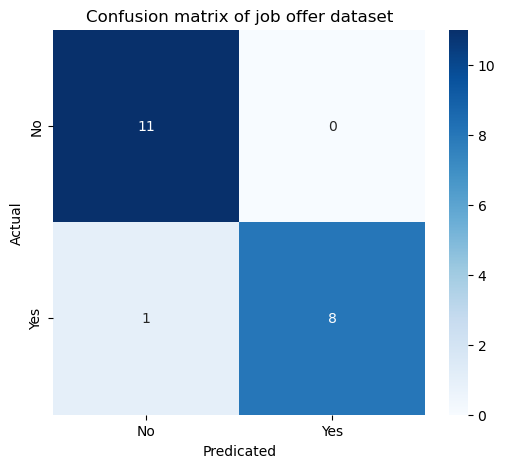

In [17]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True , xticklabels=['No','Yes'] , yticklabels=['No' , 'Yes'] , fmt = 'd' , cmap = 'Blues')
plt.xlabel("Predicated")
plt.ylabel("Actual")
plt.title("Confusion matrix of job offer dataset")
plt.show()

## Manual calculation of Evaluation metrics							
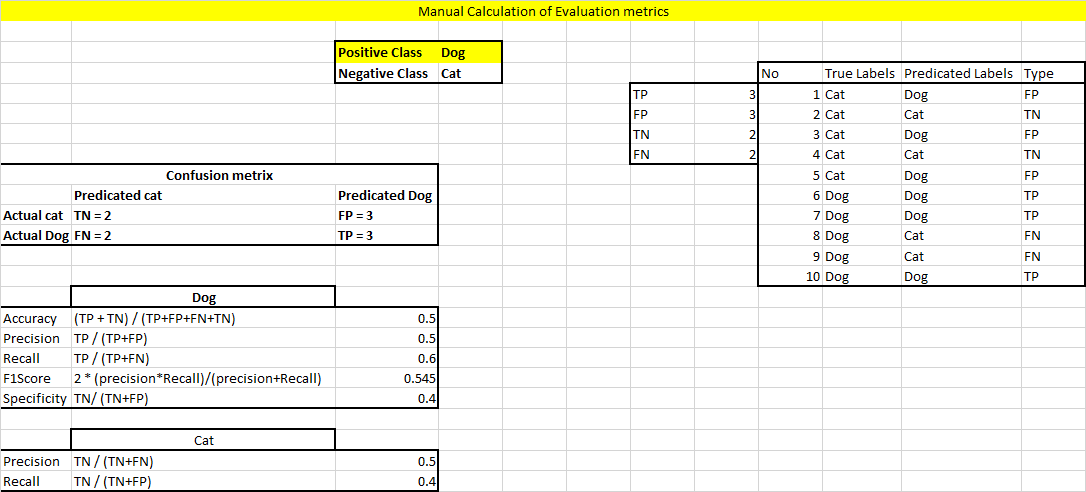

## 264
```
 Write Python code to train a decision tree classifier with entropy as the criterion using the following steps:
Initialize a Decision Tree classifier with entropy as the criterion.
Train the classifier on the training set.
Make predictions on the test set.
Calculate and print the confusion matrix for the classifier.
```
SOLUTION 
```python
# Assuming data is imported and x is the feature and y is the target 
x_train , x_test , y_train , y_test = train_test_split(
    x , y , test_size = 0.2 , random_state = 42
)
dtree = DecisionTreeClassifier(criterion = 'entropy')
dtree.fit(x_train , y_train)
y_pred = dtree.predict(x_test)
print(confusion_metrix(y_test , y_pred))
```

## 265
```
 Write Python code to evaluate the performance of a classification model using the following steps:
Import the necessary functions from sklearn.metrics.
Calculate and print the classification report for the true labels and predicted labels.
Calculate and print the accuracy score of the classifier.
```
Solution
```Python
from sklearn.metrics import classification_report , accuracy_score
print(classification_report(y , y_pred))
print(accuracy_score (y ,y_pred))
```

## 271
```
The task involves building a Decision Tree classifier to predict whether to play tennis based on weather conditions. The dataset 
used for this task is the PlayTennis dataset, which contains information about various weather attributes such as outlook, 
temperature, humidity, and wind, along with the corresponding decision to play tennis or not. Use PlayTennis.csv for dataset.

In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier 
from sklearn.metrics import confusion_matrix , accuracy_score

df = pd.read_csv('PlayTennis.csv')
df.head(2)

x = df.drop(columns= 'play')
y = df['play']
print(x.shape)
print(y.shape)

x = pd.get_dummies(x)
print(x.shape)
# x.head(2)

dtree = DecisionTreeClassifier(criterion='entropy' , max_depth=3)
dtree.fit(x,y)

predicitions = dtree.predict(x)
print(predicitions)

(14, 4)
(14,)
(14, 9)
['no' 'no' 'yes' 'no' 'yes' 'no' 'yes' 'no' 'yes' 'yes' 'no' 'yes' 'yes'
 'no']


## 274
```
Write Python code to train a Decision Tree Classifier using the following steps:
 a)Assume a sample dataset is already loaded and corresponding features and labels are already defined in the environment.
 b)Split the dataset into training and tes ng sets using 75% of the data for training and set random state of 10.
 c)Ini alize an entropy-based Decision Tree Classifier with maximum depth of 3. Use this model to make predic ons on the test 
data.
 d)Print confusion matrix and accuracy score of the classifier.
```
Solution
```python
# Assuming data is imported and x is the feature and y is the target 
x_train , x_test , y_train , y_test = train_test_split(
    x , y , test_size = 0.25 , random_state = 10
)
dtree = DecisionTreeClassifier(criterion = 'entropy' , max_depth = 3)
dtree.fit(x_train , y_train)
y_pred = dtree.predict(x_test)
print(confusion_metrix(y_test , y_pred))

### create a decision tree classification for diabitis csv file

In [2]:
df = pd.read_csv('diabetes.csv')
df.head(2)

x = df.drop(columns='Outcome')
y = df['Outcome']
print(x.shape)
print(y.shape)

dtree = DecisionTreeClassifier(criterion='entropy' , max_depth=3)
dtree.fit(x,y)

y_pred = dtree.predict(x)
print(y_pred)
print(accuracy_score(y,y_pred))
print(dtree.predict([[1,180,90,20,0,30,0.245,45]]))


(768, 8)
(768,)
[1 0 1 0 1 0 0 0 1 0 0 1 0 1 1 0 0 0 0 0 0 0 1 0 1 0 1 0 0 0 0 1 0 0 0 0 1
 0 0 0 1 1 0 1 1 1 1 0 0 0 0 0 0 1 1 0 1 0 1 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1
 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1
 1 0 0 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0
 1 0 1 0 1 1 1 1 0 0 0 1 1 0 0 0 1 0 1 0 0 0 0 1 0 0 0 1 0 1 1 1 0 0 0 0 0
 1 1 1 0 1 0 0 1 1 0 1 0 0 0 1 0 1 0 0 0 0 1 1 0 1 0 1 1 1 0 1 0 0 0 0 1 1
 0 0 0 0 0 1 1 0 1 1 0 0 0 1 1 1 1 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 0 0 0 0 1
 1 1 1 0 1 0 0 1 1 0 1 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 1 0 0 0 0 0 1 1 1 1
 1 0 0 0 1 1 0 0 1 0 1 0 1 0 0 0 1 0 0 0 0 1 0 1 0 0 0 1 0 1 0 1 0 0 0 0 1
 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 1 1 1 0 1 1 0 0 0 0 1
 1 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 1 0 1 0 0 1 0 1 0 0
 0 1 1 0 0 1 0 1 1 0 1 0 0 0 0 0 0 1 1 0 1 1 0 0 0 0 0 0 1 1 1 0 0 1 0 0 0
 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 1
 0 0 0 1 

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# Python Implementation

In [10]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
import matplotlib.pyplot as plt

# Data
x = np.array([[1,6],[2,7],[6,3],[7,2]])
y = np.array([-1,-1,1,1])
# Model
model = SVC(kernel='linear')
# fit
model.fit(x,y)
# parameters
w = model.coef_[0]
b = model.intercept_[0]
print("Slope / Weight is : ",w)
print("Intercept / Bias is : ",b)

Slope / Weight is :  [ 0.25 -0.25]
Intercept / Bias is :  0.25


# Plot the Scatter and decision boundry

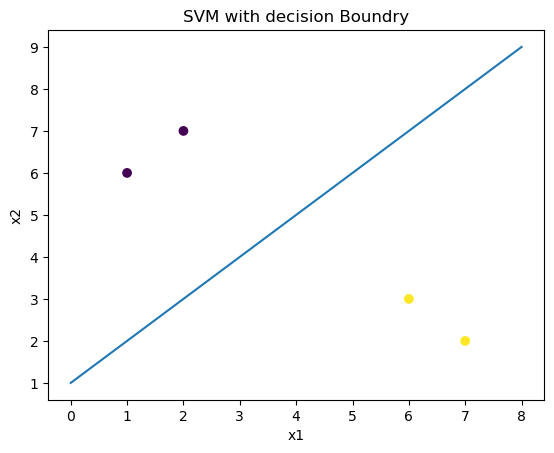

In [17]:
plt.scatter(x[:,0] , x[:,1] , c=y)
# Decision boundry
xval = np.linspace(0,8,100)
yval = -(w[0]*xval + b)/w[1]
plt.plot(xval , yval)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('SVM with decision Boundry')
plt.show()

In [15]:

# prediction
newpoints = np.array([[3,6],[5,3],[4,5]])
model.predict(newpoints)

array([-1,  1,  1])

# KNN Algorithm

In [21]:
# import libraries
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

# Define feature and target
x = np.array([[7,7],[7,4],[3,4],[1,4]])
y = np.array(['Bad','Bad','Good','Good'])
# model creation
knn = KNeighborsClassifier(n_neighbors=3)
# fit the model
knn.fit(x,y)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


## predicate for the query point

In [23]:
knn.predict([[3,7]])

array(['Good'], dtype='<U4')

# 263
```
 Write Python code to train a kNN classifier using the following steps:
Split the dataset X into training and testing sets with a test size of 0.3 and a random state of 42.
Initialize a kNN classifier with 5 neighbors.
Train the classifier on the training set.
Make predictions on the test set.
Calculate and print the accuracy score of the classifier.
```
Solution
```python
# import libraries
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Assuming the data is loaded and x and y are defined
x_train,x_test,y_train,y_test = train_test_split(
    x , y , test_size = 0.3 , random_state = 42
)
# create model
model = KNeighborsClassifier(n_neighbors = 5)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(accuracy_score(y_test , y_pred))

# 267
```
You are tasked with using the k-Nearest Neighbors (kNN) algorithm to classify whether patients have diabetes or not based on 
certain diagnostic measurements. You have been provided with diabetes.csv file. The datasets consist of several medical 
predictor (independent) variables and one target (dependent) variable, Outcome. Independent variables include the number of 
pregnancies the patient has had, their BMI, insulin level, age, and so on. Also perform Model Performance Analysis using 
confusion matrix.
```

In [42]:
# import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix , accuracy_score
from sklearn.neighbors import KNeighborsClassifier

# load the data
df = pd.read_csv('diabetes.csv')
df.head(2)

x = df.drop(columns = 'Outcome')
y = df['Outcome']
print(x.shape)
print(y.shape)
x_train,x_test,y_train,y_test = train_test_split(
    x , y , test_size = 0.25 , random_state = 42
)
# model
model = KNeighborsClassifier(n_neighbors=5)
model.fit(x_train , y_train)
y_pred = model.predict(x_test)
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test , y_pred))

(768, 8)
(768,)
0.65625
[[88 35]
 [31 38]]


In [40]:
# extra
print(model.predict([[1,200,180,25,0,30,0.342,45]]))

[1]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


# Random Forest Algorithem

## Python Implementation

In [6]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier

# define features and target
x = np.array([[1,6],[2,7],[6,3],[7,2]])  # x1 hours of study ; x2 hours of sleep
y = np.array([0,0,1,1]) # 0 means fail , 1 means pass
# create model
rf = RandomForestClassifier(n_estimators=10 , max_depth=2 , random_state=42)
# fit the model
rf.fit(x,y)

,n_estimators,10
,criterion,'gini'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [10]:
# predict for new points
new_points = np.array([[3,6],[5,3],[4,5]])
print(rf.predict(new_points))

[0 1 1]


# 313
```
 Random Forest Classifier Implementation
Write Python code to implement a Random Forest Classifier using the following instructions:
Initialize the classifier with:
n_estimators = 100
random_state = 42
Train the model using training data.
Predict class labels for test data.
Evaluate the model by calculating:
Confusion Matrix
Accuracy score
```
SOLUTION
```python
# import the libraries
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix , accuracy_score
# Assuming that x and y are defined from the dataset
x_train , x_test , y_train , y_test = train_test_split(
    x , y , random_state=42 , test_size=0.2
)
rf = RandomForestClassifier(n_estimators=100 , random_state=42)
rf.fit(x_train , y_train)
y_pred = rf.predict(x_test)
print("prediction : " , y_pred)
print(rf.confusion_matrix(y_test , y_pred))
print(rf.accuracy_score(y_test , y_pred))

# 273
```
 You have been provided with a dataset named students_performance.csv, which contains various features related to students' 
performance in exams. The dataset includes features such as gender, race/ethnicity, parental level of education, lunch, test 
preparation course, and scores in math, reading, and writing. Your task is to perform classification to predict whether a student 
will pass or fail based on these features.
Steps to complete:
 1.Load the Dataset:
 oLoad the dataset students_performance.csv into a pandas DataFrame.
 oDisplay the first few rows to understand the structure of the dataset and check the sta s cs.
 2.Preprocessing:
 oConvert the scores in math, reading, and wri ng to a binary pass/fail label. Consider a score of 50 or above as pass(1) and 
below 50 as fail(0).
 oDrop the scores in math, reading, and wri ng.
 oCreate a new Column named ‘Overall_Pass’ and create a binary label: pass(1) if Student passes all heads (math, reading, and 
writing) and fail(0) if student has failed in even one head.
 oEncode categorical variables (gender, race/ethnicity, parental level of educa on, lunch, test prepara on course) using one
hot encoding.
 oHandle any missing values if present.
 oSplit the dataset into features (x) and target (y) where the target is the pass/fail label for the math pass.
 oSplit the data into training (80%) sets using random state 10.

In [14]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix , accuracy_score

In [26]:
# 1 Load the dataset
df = pd.read_csv("https://raw.githubusercontent.com/patelmanishv/Sem4Data/refs/heads/main/Datasets/StudentsPerformance.csv")
df.head(2)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


In [27]:
# 2. preprocessing
# Convert the scores in math, reading, and wri ng to a binary pass/fail label. Consider a score of 50 or above as pass(1) and 
# below 50 as fail(0).
df['math_pass'] = np.where(df['math score'] >= 50 , 1 ,0)
df['reading_pass'] = np.where(df['reading score'] >= 50 , 1 ,0)
df['writing_pass'] = np.where(df['writing score'] >= 50 , 1 ,0)

In [28]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,math_pass,reading_pass,writing_pass
0,female,group B,bachelor's degree,standard,none,72,72,74,1,1,1
1,female,group C,some college,standard,completed,69,90,88,1,1,1
2,female,group B,master's degree,standard,none,90,95,93,1,1,1
3,male,group A,associate's degree,free/reduced,none,47,57,44,0,1,0
4,male,group C,some college,standard,none,76,78,75,1,1,1


In [29]:
# Drop the scores in math, reading, and wri ng
df.drop(columns=['math score' , 'reading score' , 'writing score'] , inplace = True)
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math_pass,reading_pass,writing_pass
0,female,group B,bachelor's degree,standard,none,1,1,1
1,female,group C,some college,standard,completed,1,1,1
2,female,group B,master's degree,standard,none,1,1,1
3,male,group A,associate's degree,free/reduced,none,0,1,0
4,male,group C,some college,standard,none,1,1,1


In [30]:
df['Overall_pass'] = np.where(
    (df['math_pass'] == 1) &
    (df['reading_pass'] == 1) &
    (df['writing_pass'] == 1) , 1 , 0 
)

In [32]:
# one hot encoding / get dummies
categorical = ['gender' , 'race/ethnicity' , 'parental level of education' , 'lunch' , 'test preparation course']
df_encoded = pd.get_dummies(df.drop(columns = ['math_pass']) , columns=categorical , drop_first=True)

In [36]:
# Handle any missing values if present
df_encoded.isna().sum()

reading_pass                                     0
writing_pass                                     0
Overall_pass                                     0
gender_male                                      0
race/ethnicity_group B                           0
race/ethnicity_group C                           0
race/ethnicity_group D                           0
race/ethnicity_group E                           0
parental level of education_bachelor's degree    0
parental level of education_high school          0
parental level of education_master's degree      0
parental level of education_some college         0
parental level of education_some high school     0
lunch_standard                                   0
test preparation course_none                     0
dtype: int64

In [37]:
# split the data
x = df_encoded
y = df['math_pass']
print(x.shape)
print(y.shape)

(1000, 15)
(1000,)


In [38]:
# train test split
x_train , x_test , y_train , y_test = train_test_split(
    x , y , test_size=0.2 , random_state=10
)

In [42]:
##### KNN classifier #####
# to find best k for the model
best_k = 1
best_accuracy = 0
for k in range(1,21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train , y_train)
    pred = knn.predict(x_test)
    acc = accuracy_score(y_test , pred)
    if acc > best_accuracy:
        best_k = k
        best_accuracy = acc
print(best_k)
print(best_accuracy)

2
0.935


In [43]:
# predict using the best k
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(x_train , y_train)
y_pred_knn = knn.predict(x_test)
cm_knn = confusion_matrix(y_test , y_pred_knn)
accuracy_knn = accuracy_score(y_test , y_pred_knn)
tn,fp,fn,tp = cm_knn.ravel()
sensitivity_knn = tp / (tp + fn)
specificity_knn = tn / (tn + fp)
print("KNN accuracy is : ",accuracy_knn)

KNN accuracy is :  0.935
